In [66]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
conn = sqlite3.connect("../../data/fuente_cxc.sqlite")
df = pd.read_sql("SELECT * FROM tabla1", conn)
df.head()

,cod_apli_prod,descri_cod_apli_prod,num_cta,f_creacion,f_ultimo_pago,vlr_original,vlr_pagado,vlr_pendiente_pago,cod_trn,descri_cod_trn,year,month,day
0,S,AHORRO,84443321151,20250211,20250411,154.08,154.08,0.00,1517,COBRO SERVICIO TRANSPORTE,2025,10,11
1,S,AHORRO,85352974856,20241103,20250921,1278.25,1278.25,0.00,2107,CARGO FISCAL IVA TRASLADO,2025,10,11
2,S,AHORRO,97822810913,20250501,20250625,5646.89,5646.89,0.00,834,CARGO FISCAL TRANSACCIONAL,2025,10,11
3,S,AHORRO,38571076870,20241222,20250714,285.77,257.19,28.58,834,CARGO FISCAL TRANSACCIONAL,2025,10,11
4,S,AHORRO,92759986619,20250222,20250901,17048.76,17048.76,0.00,834,CARGO FISCAL TRANSACCIONAL,2025,10,11


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21739 entries, 0 to 21738
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cod_apli_prod         21739 non-null  str    
 1   descri_cod_apli_prod  21739 non-null  str    
 2   num_cta               21739 non-null  int64  
 3   f_creacion            21739 non-null  int64  
 4   f_ultimo_pago         21739 non-null  int64  
 5   vlr_original          21739 non-null  float64
 6   vlr_pagado            21739 non-null  float64
 7   vlr_pendiente_pago    21739 non-null  float64
 8   cod_trn               21739 non-null  int64  
 9   descri_cod_trn        21739 non-null  str    
 10  year                  21739 non-null  int64  
 11  month                 21739 non-null  int64  
 12  day                   21739 non-null  int64  
dtypes: float64(3), int64(7), str(3)
memory usage: 2.2 MB


In [7]:
df.describe()

,num_cta,f_creacion,f_ultimo_pago,vlr_original,vlr_pagado,vlr_pendiente_pago,cod_trn,year,month,day
count,2.173900e+04,2.173900e+04,2.173900e+04,21739.000000,21739.000000,21739.000000,21739.000000,21739.0,21739.000000,21739.000000
mean,5.536941e+10,2.024823e+07,2.025048e+07,6512.012937,5491.266799,1020.746138,1057.808593,2025.0,10.342794,15.861171
std,2.586625e+10,3.937081e+03,1.419011e+03,19140.521465,17918.782539,5955.033068,626.909996,0.0,0.474654,8.857229
min,1.006355e+10,2.024101e+07,2.024102e+07,36.330000,0.000000,0.000000,67.000000,2025.0,10.000000,1.000000
25%,3.336234e+10,2.025010e+07,2.025051e+07,856.605000,567.025000,0.000000,627.000000,2025.0,10.000000,8.000000
50%,5.526215e+10,2.025031e+07,2.025072e+07,2218.190000,1782.250000,0.000000,834.000000,2025.0,10.000000,16.000000
75%,7.770340e+10,2.025052e+07,2.025091e+07,6001.660000,5041.595000,0.000000,1517.000000,2025.0,11.000000,24.000000
max,9.979543e+10,2.025081e+07,2.025111e+07,446887.020000,446887.020000,173830.090000,2477.000000,2025.0,11.000000,31.000000


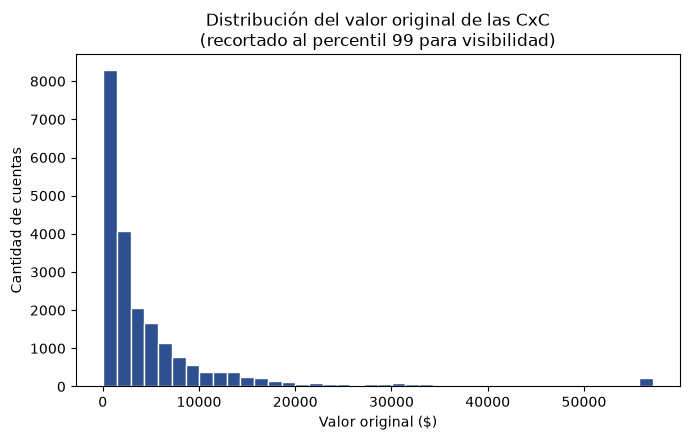

In [91]:
# Distribución del valor original de las CxC
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(df['vlr_original'].clip(upper=df['vlr_original'].quantile(0.99)), bins=40, color='#2E5090', edgecolor='white')
ax.set_title('Distribución del valor original de las CxC\n(recortado al percentil 99 para visibilidad)')
ax.set_xlabel('Valor original ($)')
ax.set_ylabel('Cantidad de cuentas')
plt.tight_layout()
plt.savefig('../../docs/actividad1/01_distribucion_valor_original.png', dpi=150)
plt.show()

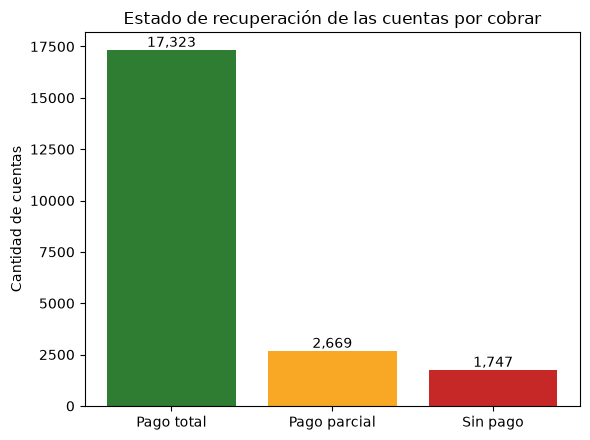

In [98]:
# Estado de recuperación (pago total / parcial / sin pago)
pago_total   = (df['vlr_pendiente_pago'] == 0)
sin_pago = (df['vlr_pagado'] == 0)
pago_parcial  = (df['vlr_pagado'] > 0) & (df['vlr_pendiente_pago'] > 0)

conteo = pd.Series({
    'Pago total': pago_total.sum(),
    'Pago parcial': pago_parcial.sum(),
    'Sin pago': sin_pago.sum()
})

fig, ax = plt.subplots(figsize=(6, 4.5))
colors = ['#2E7D32', '#F9A825', '#C62828']
bars = ax.bar(conteo.index, conteo.values, color=colors)
bars
for b in bars:
    h = b.get_height()
    ax.annotate(f'{h:,}',
                (b.get_x() + b.get_width()/2, h),
                ha='center', va='bottom')
ax.set_title('Estado de recuperación de las cuentas por cobrar')
ax.set_ylabel('Cantidad de cuentas')
plt.tight_layout()
plt.savefig('../../docs/actividad1/02_estado_recuperacion.png', dpi=150)
plt.show()

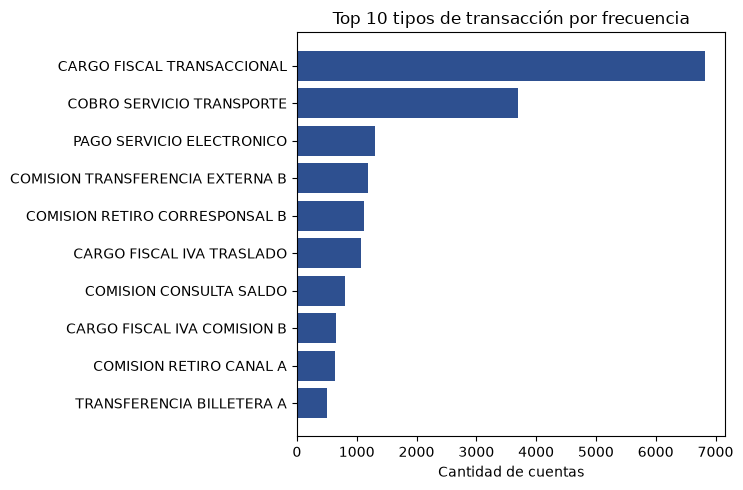

In [110]:
top_trn = df['descri_cod_trn'].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh(top_trn.index, top_trn.values, color='#2E5090')
ax.set_title('Top 10 tipos de transacción por frecuencia')
ax.set_xlabel('Cantidad de cuentas')
plt.tight_layout()
plt.savefig('../../docs/actividad1/03_top_tipos_transaccion.png', dpi=150)
plt.show()

In [109]:
print(f"Total registros: {len(df):,}")
print(f"Pago total: {pago_total.sum():,} ({pago_total.mean()*100:.1f}%)")
print(f"Pago parcial: {pago_parcial.sum():,} ({pago_parcial.mean()*100:.1f}%)")
print(f"Sin pago: {sin_pago.sum():,} ({sin_pago.mean()*100:.1f}%)")
print(f"Producto más frecuente: {df['descri_cod_apli_prod'].value_counts().idxmax()} ({df['descri_cod_apli_prod'].value_counts(normalize=True).max()*100:.1f}%)")
print(f"Transacción más frecuente: {df['descri_cod_trn'].value_counts().idxmax()} ({df['descri_cod_trn'].value_counts().max():,} casos)")
print(f"Cantidad total de transacciones: {df['descri_cod_trn'].nunique()}")

Total registros: 21,739
Pago total: 17,323 (79.7%)
Pago parcial: 2,669 (12.3%)
Sin pago: 1,747 (8.0%)
Producto más frecuente: AHORRO (98.9%)
Transacción más frecuente: CARGO FISCAL TRANSACCIONAL (6,823 casos)
Cantidad total de transacciones: 71


In [65]:
with open("../../src/sql/queries.sql") as f:
    query = f.read()

sabana = pd.read_sql(query, conn)

# Pagadas totalmente
print("Total de cuentas pagadas totalmente: ", sabana['pago_total'].sum())

# Pagadas parcialmente
print("Total de cuentas pagadas parcialmente:", sabana['pago_parcial'].sum())

# Sin ningún pago
print("Total de cuentas sin pagar:", sabana['sin_pago'].sum())

sabana.to_csv("../../src/data/sabana_cxc.csv", index=False)

Total de cuentas pagadas totalmente:  17323
Total de cuentas pagadas parcialmente: 2669
Total de cuentas sin pagar: 1747
